In [1]:
# Block 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Block 2 - Create Current Workforce Dataset
np.random.seed(42)

departments = ['Operations', 'Finance', 'HR', 'IT', 'Sales', 'Legal']

data = {
    'department': departments,
    'current_headcount': [320, 180, 85, 210, 145, 60],
    'target_headcount': [380, 200, 90, 260, 175, 70],
    'attrition_rate_pct': [14.0, 12.0, 10.0, 16.0, 18.0, 8.0],
    'internal_mobility_rate_pct': [3.0, 4.0, 5.0, 6.0, 4.0, 3.0],
    'avg_time_to_fill_days': [45, 40, 35, 55, 30, 50],
    'avg_monthly_salary': [18000, 22000, 16000, 25000, 20000, 28000]
}

df = pd.DataFrame(data)

print("=== Current Workforce Snapshot ===")
print(df.to_string(index=False))
print(f"\nTotal current headcount: {df['current_headcount'].sum():,}")
print(f"Total target headcount:  {df['target_headcount'].sum():,}")
print(f"Total gap to fill:       {(df['target_headcount'] - df['current_headcount']).sum():,}")

=== Current Workforce Snapshot ===
department  current_headcount  target_headcount  attrition_rate_pct  internal_mobility_rate_pct  avg_time_to_fill_days  avg_monthly_salary
Operations                320               380                14.0                         3.0                     45               18000
   Finance                180               200                12.0                         4.0                     40               22000
        HR                 85                90                10.0                         5.0                     35               16000
        IT                210               260                16.0                         6.0                     55               25000
     Sales                145               175                18.0                         4.0                     30               20000
     Legal                 60                70                 8.0                         3.0                     50             

In [3]:
# Block 3 - Calculate Gross Hiring Need Per Department
df['net_gap'] = df['target_headcount'] - df['current_headcount']

# Annual attrition backfill needed
df['attrition_backfill'] = np.round(
    df['current_headcount'] * (df['attrition_rate_pct'] / 100), 0
).astype(int)

# Internal mobility loss (employees leaving department)
df['mobility_loss'] = np.round(
    df['current_headcount'] * (df['internal_mobility_rate_pct'] / 100), 0
).astype(int)

# Gross hiring need = growth gap + attrition backfill + mobility loss
df['gross_hiring_need'] = df['net_gap'] + df['attrition_backfill'] + df['mobility_loss']

# Annual cost of hiring plan
df['annual_hiring_cost'] = df['gross_hiring_need'] * df['avg_monthly_salary'] * 3

print("=== Gross Hiring Plan by Department ===")
print(df[['department', 'net_gap', 'attrition_backfill', 
          'mobility_loss', 'gross_hiring_need']].to_string(index=False))
print(f"\nTotal gross hires needed:     {df['gross_hiring_need'].sum():,}")
print(f"Total net gap:                {df['net_gap'].sum():,}")
print(f"Total attrition backfill:     {df['attrition_backfill'].sum():,}")
print(f"Total mobility loss backfill: {df['mobility_loss'].sum():,}")
print(f"\nEstimated total hiring cost:  {df['annual_hiring_cost'].sum():,.0f} AED")

=== Gross Hiring Plan by Department ===
department  net_gap  attrition_backfill  mobility_loss  gross_hiring_need
Operations       60                  45             10                115
   Finance       20                  22              7                 49
        HR        5                   8              4                 17
        IT       50                  34             13                 97
     Sales       30                  26              6                 62
     Legal       10                   5              2                 17

Total gross hires needed:     357
Total net gap:                175
Total attrition backfill:     140
Total mobility loss backfill: 42

Estimated total hiring cost:  22,683,000 AED


In [4]:
# Block 4 - Quarterly Hiring Plan
quarters = ['Q1', 'Q2', 'Q3', 'Q4']

# Hiring spread assumption:
# Q1 - 20% (slow start, planning phase)
# Q2 - 30% (ramp up)
# Q3 - 30% (peak hiring)
# Q4 - 20% (slowdown, budget freeze)
spread = [0.20, 0.30, 0.30, 0.20]

quarterly_plan = []

for _, row in df.iterrows():
    for i, quarter in enumerate(quarters):
        hires = np.round(row['gross_hiring_need'] * spread[i], 0).astype(int)
        quarterly_plan.append({
            'department': row['department'],
            'quarter': quarter,
            'planned_hires': hires,
            'avg_time_to_fill_days': row['avg_time_to_fill_days'],
            'quarterly_cost': hires * row['avg_monthly_salary'] * 3
        })

qdf = pd.DataFrame(quarterly_plan)

# Pivot for clean view
pivot = qdf.pivot_table(
    index='department',
    columns='quarter',
    values='planned_hires',
    aggfunc='sum'
)
pivot['Total'] = pivot.sum(axis=1)

print("=== Quarterly Hiring Plan (Number of Hires) ===")
print(pivot.to_string())
print(f"\nTotal hires per quarter:")
for q in quarters:
    total = qdf[qdf['quarter']==q]['planned_hires'].sum()
    cost = qdf[qdf['quarter']==q]['quarterly_cost'].sum()
    print(f"  {q}: {total:>3} hires  |  Cost: {cost:>12,.0f} AED")

=== Quarterly Hiring Plan (Number of Hires) ===
quarter     Q1  Q2  Q3  Q4  Total
department                       
Finance     10  15  15  10     50
HR           3   5   5   3     16
IT          19  29  29  19     96
Legal        3   5   5   3     16
Operations  23  34  34  23    114
Sales       12  19  19  12     62

Total hires per quarter:
  Q1:  70 hires  |  Cost:    4,443,000 AED
  Q2: 107 hires  |  Cost:    6,801,000 AED
  Q3: 107 hires  |  Cost:    6,801,000 AED
  Q4:  70 hires  |  Cost:    4,443,000 AED


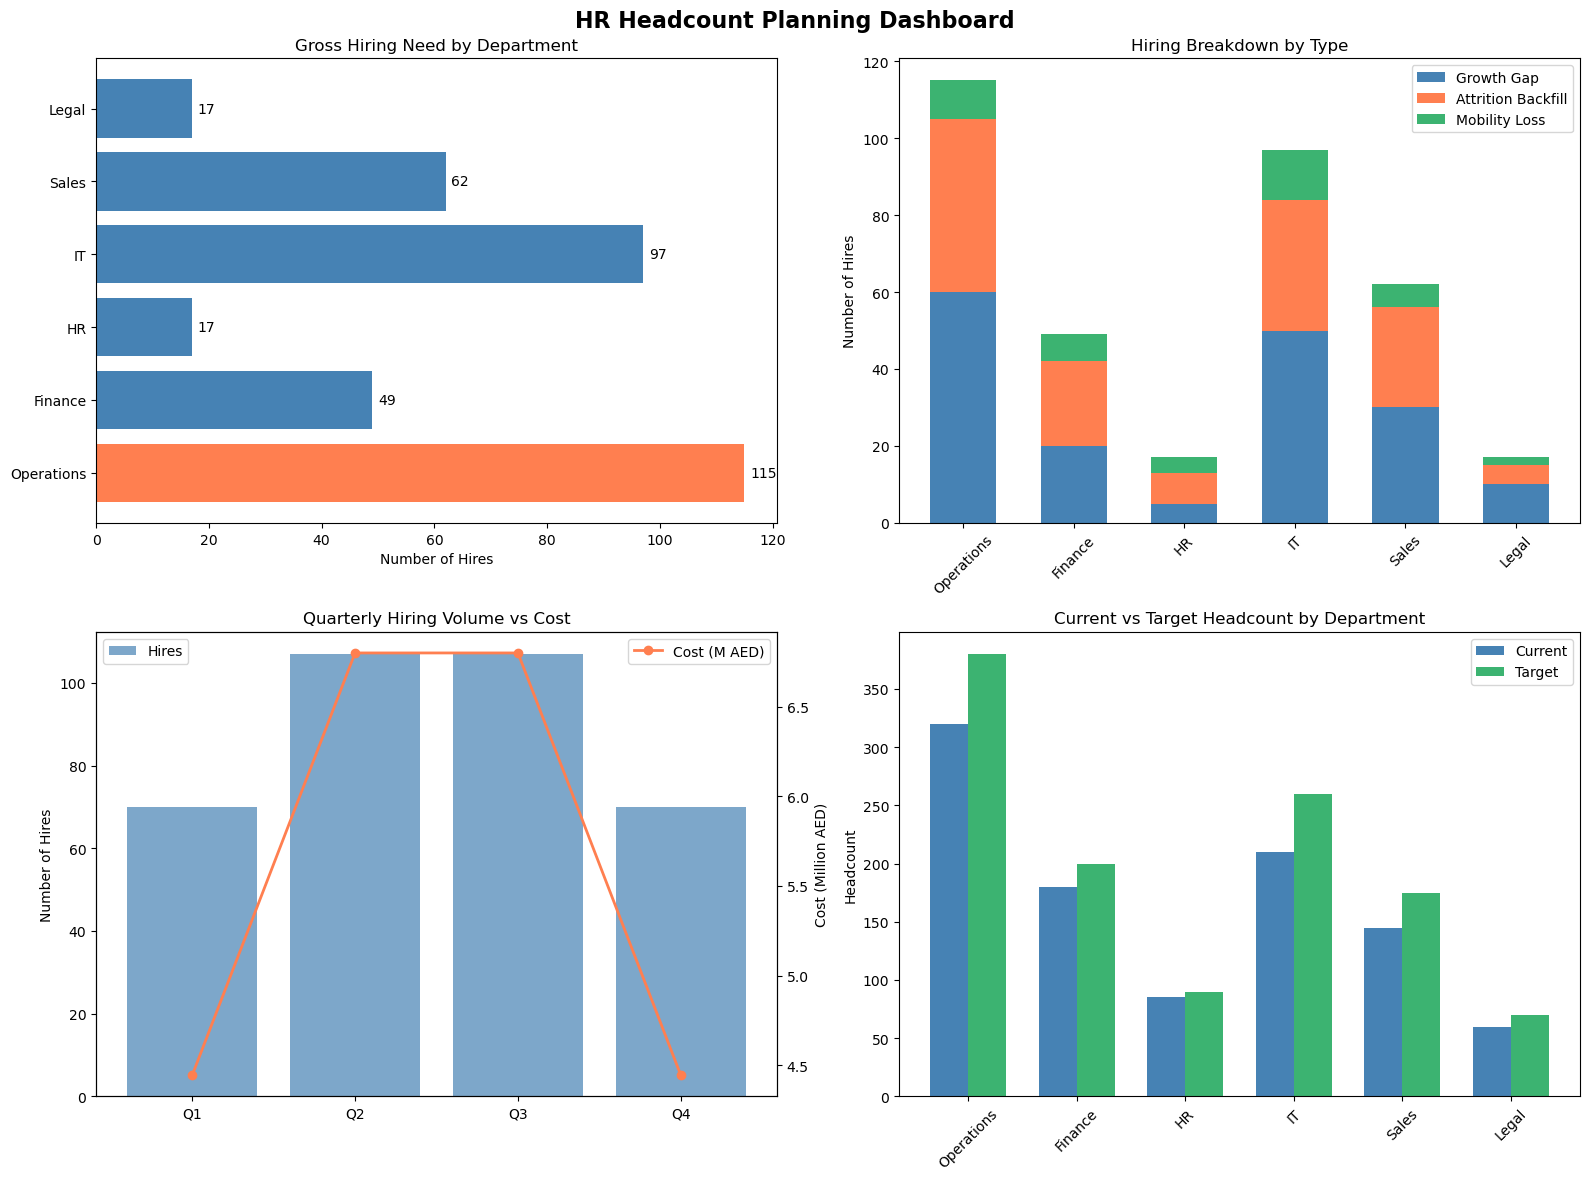

Dashboard saved as headcount_plan_dashboard.png


In [5]:
# Block 5 - Visualise the Headcount Plan
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('HR Headcount Planning Dashboard', fontsize=16, fontweight='bold')

# Chart 1 - Gross Hiring Need by Department
colors = ['coral' if x == df['gross_hiring_need'].max() 
          else 'steelblue' for x in df['gross_hiring_need']]
axes[0,0].barh(df['department'], df['gross_hiring_need'], color=colors)
axes[0,0].set_title('Gross Hiring Need by Department')
axes[0,0].set_xlabel('Number of Hires')
for i, v in enumerate(df['gross_hiring_need']):
    axes[0,0].text(v + 1, i, str(v), va='center', fontsize=10)

# Chart 2 - Hiring Breakdown (Stacked Bar)
x = np.arange(len(df['department']))
width = 0.6
axes[0,1].bar(x, df['net_gap'], width, label='Growth Gap', color='steelblue')
axes[0,1].bar(x, df['attrition_backfill'], width, 
              bottom=df['net_gap'], label='Attrition Backfill', color='coral')
axes[0,1].bar(x, df['mobility_loss'], width,
              bottom=df['net_gap']+df['attrition_backfill'], 
              label='Mobility Loss', color='mediumseagreen')
axes[0,1].set_title('Hiring Breakdown by Type')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(df['department'], rotation=45)
axes[0,1].set_ylabel('Number of Hires')
axes[0,1].legend()

# Chart 3 - Quarterly Hiring Volume
q_totals = qdf.groupby('quarter')['planned_hires'].sum()
q_costs = qdf.groupby('quarter')['quarterly_cost'].sum() / 1_000_000
ax2 = axes[1,0].twinx()
axes[1,0].bar(q_totals.index, q_totals.values, color='steelblue', alpha=0.7, label='Hires')
ax2.plot(q_costs.index, q_costs.values, color='coral', 
         marker='o', linewidth=2, label='Cost (M AED)')
axes[1,0].set_title('Quarterly Hiring Volume vs Cost')
axes[1,0].set_ylabel('Number of Hires')
ax2.set_ylabel('Cost (Million AED)')
axes[1,0].legend(loc='upper left')
ax2.legend(loc='upper right')

# Chart 4 - Headcount Gap Analysis
x = np.arange(len(df['department']))
width = 0.35
axes[1,1].bar(x - width/2, df['current_headcount'], width, 
              label='Current', color='steelblue')
axes[1,1].bar(x + width/2, df['target_headcount'], width, 
              label='Target', color='mediumseagreen')
axes[1,1].set_title('Current vs Target Headcount by Department')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(df['department'], rotation=45)
axes[1,1].set_ylabel('Headcount')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('headcount_plan_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved as headcount_plan_dashboard.png")

In [6]:
# Block 6 - Export Final Hiring Plan
# Full quarterly plan with costs
output = qdf[['department', 'quarter', 'planned_hires', 
              'avg_time_to_fill_days', 'quarterly_cost']].copy()

output = output.sort_values(['department', 'quarter'])

# Add cumulative hires per department
output['cumulative_hires'] = output.groupby('department')['planned_hires'].cumsum()

# Add hiring urgency flag
output['urgency'] = output.apply(
    lambda row: 'High' if row['avg_time_to_fill_days'] >= 50 
    else ('Medium' if row['avg_time_to_fill_days'] >= 35 else 'Standard'), axis=1
)

print("=== Final Quarterly Hiring Plan ===")
print(output.to_string(index=False))

# Summary by quarter
print("\n=== Executive Summary ===")
print(f"Total headcount growth required:  {df['net_gap'].sum():,} employees")
print(f"Total gross hires required:       {df['gross_hiring_need'].sum():,} employees")
print(f"Peak hiring quarter:              Q2 & Q3 ({qdf[qdf['quarter']=='Q2']['planned_hires'].sum()} hires each)")
print(f"Highest risk department:          IT (55 days avg time to fill)")
print(f"Total annual hiring investment:   {df['annual_hiring_cost'].sum():,.0f} AED")

# Save to CSV
output.to_csv('headcount_hiring_plan.csv', index=False)
print("\nHiring plan saved to headcount_hiring_plan.csv")

=== Final Quarterly Hiring Plan ===
department quarter  planned_hires  avg_time_to_fill_days  quarterly_cost  cumulative_hires  urgency
   Finance      Q1             10                     40          660000                10   Medium
   Finance      Q2             15                     40          990000                25   Medium
   Finance      Q3             15                     40          990000                40   Medium
   Finance      Q4             10                     40          660000                50   Medium
        HR      Q1              3                     35          144000                 3   Medium
        HR      Q2              5                     35          240000                 8   Medium
        HR      Q3              5                     35          240000                13   Medium
        HR      Q4              3                     35          144000                16   Medium
        IT      Q1             19                     55        